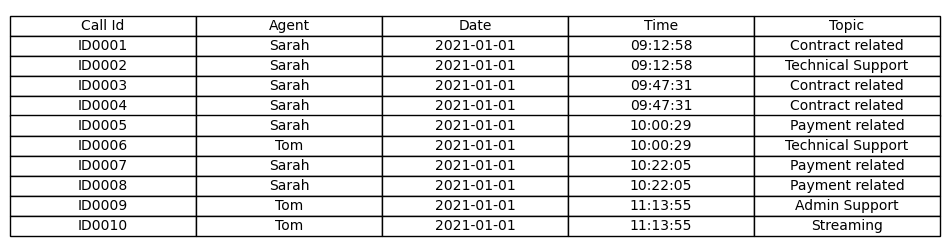

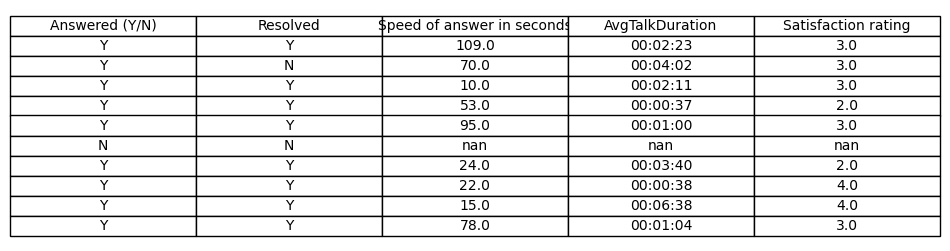

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取 Excel 文件
df = pd.read_excel("ModifiedCallCenterTwo.xlsx")

# 取前10行
top_10 = df.head(10)

# 将列分成两部分
columns_part1 = top_10.columns[:5]   # 前5列
columns_part2 = top_10.columns[5:]   # 后5列

# 表格1（前半列）
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(cellText=top_10[columns_part1].values,
                 colLabels=columns_part1,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("top_10_part1.png", bbox_inches='tight')
plt.show()

# 表格2（后半列）
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table = ax.table(cellText=top_10[columns_part2].values,
                 colLabels=columns_part2,
                 cellLoc='center',
                 loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)
plt.savefig("top_10_part2.png", bbox_inches='tight')
plt.show()

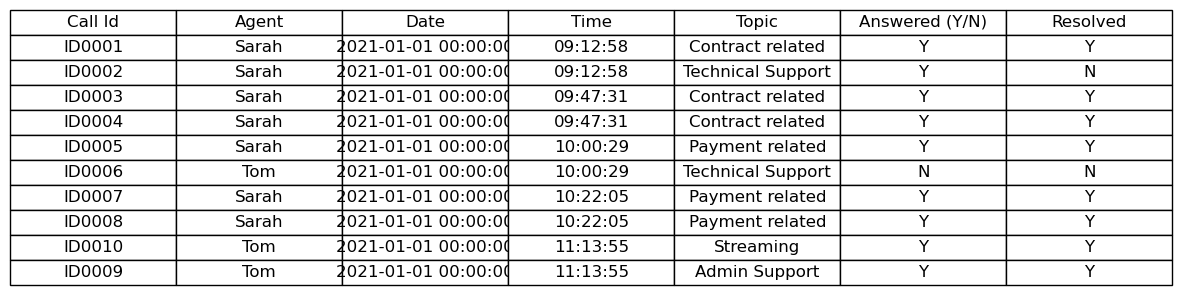

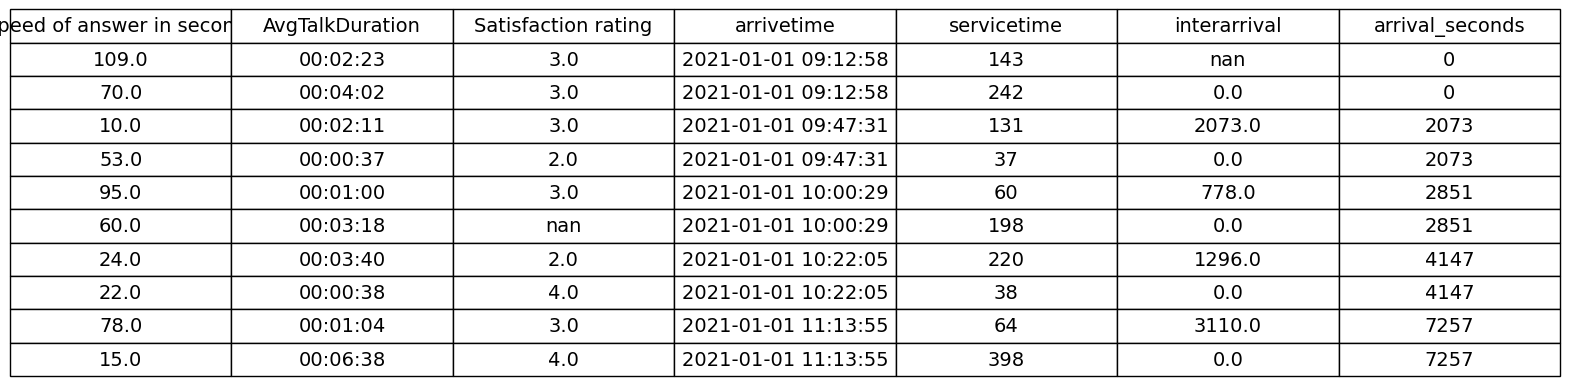

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取处理后的数据
processed_path = "Preprocessed_ModifiedCallCenterTwo.xlsx"
df_processed = pd.read_excel(processed_path)

# 取前10行
top_10_processed = df_processed.head(10)

# 拆分列为两部分（平均分配）
mid_index = len(top_10_processed.columns) // 2
columns_part1 = top_10_processed.columns[:mid_index]
columns_part2 = top_10_processed.columns[mid_index:]

# 表格1：前半部分
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table1 = ax.table(cellText=top_10_processed[columns_part1].values,
                  colLabels=columns_part1,
                  cellLoc='center',
                  loc='center')
table1.auto_set_font_size(False)
table1.set_fontsize(12)
table1.scale(1.5, 1.5)
plt.savefig("top_10_processed_part1.png", bbox_inches='tight')
plt.show()

# 表格2：后半部分
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
table2 = ax.table(cellText=top_10_processed[columns_part2].values,
                  colLabels=columns_part2,
                  cellLoc='center',
                  loc='center')
table2.auto_set_font_size(False)
table2.set_fontsize(14)
table2.scale(2, 2)
plt.savefig("top_10_processed_part2.png", bbox_inches='tight')
plt.show()


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kstest, expon

# -----------------------
# 1. Data Preprocessing
# -----------------------

# Load the original call center dataset (Excel format)
df = pd.read_excel("ModifiedCallCenterTwo.xlsx")

# Convert the "AvgTalkDuration" column from string format (e.g., "00:02:23") 
# into a timedelta object, then extract the duration in seconds
df['AvgTalkDuration_seconds'] = pd.to_timedelta(df['AvgTalkDuration']).dt.total_seconds()

# Clean column names by stripping extra spaces (if any)
df.columns = df.columns.str.strip()
print("Columns in DataFrame:", df.columns.tolist())

# Convert relevant numeric columns (that might be stored as strings) into numeric types
# Coerce invalid values to NaN (e.g., non-numeric text)
df['Speed of answer in seconds'] = pd.to_numeric(df['Speed of answer in seconds'], errors='coerce')
df['Satisfaction rating'] = pd.to_numeric(df['Satisfaction rating'], errors='coerce')

# Compute medians for each column to handle missing values
median_talk = df['AvgTalkDuration_seconds'].median()
median_speed = df['Speed of answer in seconds'].median()
median_satisfaction = df['Satisfaction rating'].median()

# Fill missing values with the median value of each respective column
df['AvgTalkDuration_seconds'].fillna(median_talk, inplace=True)
df['Speed of answer in seconds'].fillna(median_speed, inplace=True)
df['Satisfaction rating'].fillna(median_satisfaction, inplace=True)

# Create two new columns:
# 'arrivetime': combine "Date" and "Time" fields into a complete datetime
# 'servicetime': duplicate column for service duration (in seconds)
df['arrivetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df['servicetime'] = df['AvgTalkDuration_seconds']

# Sort the data chronologically by arrival time
# Then compute 'interarrival' time, i.e., the time gap (in seconds) between consecutive calls
df.sort_values('arrivetime', inplace=True)
df['interarrival'] = df['arrivetime'].diff().dt.total_seconds()

# Convert absolute arrival times to relative time in seconds from the first call
# This helps standardize the timeline for simulation and modeling
df['arrival_seconds'] = (df['arrivetime'] - df['arrivetime'].min()).dt.total_seconds()

# Save the cleaned and processed dataset into a new Excel file
# This will be used for simulation and analysis in later parts of the project
df.to_excel("PreprocessedModifiedCallCenterTwo.xlsx", index=False)
print("Processed data saved to Preprocessed_ModifiedCallCenterTwo.xlsx")


Columns in DataFrame: ['Call Id', 'Agent', 'Date', 'Time', 'Topic', 'Answered (Y/N)', 'Resolved', 'Speed of answer in seconds', 'AvgTalkDuration', 'Satisfaction rating', 'AvgTalkDuration_seconds']


/var/folders/m8/z0s71_vs7glbsmd84zt1dx6r0000gn/T/ipykernel_60546/3133071631.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['AvgTalkDuration_seconds'].fillna(median_talk, inplace=True)
/var/folders/m8/z0s71_vs7glbsmd84zt1dx6r0000gn/T/ipykernel_60546/3133071631.py:33: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

Processed data saved to Preprocessed_ModifiedCallCenterTwo.xlsx


0      2021-01-01 09:00:00
1      2021-01-01 09:00:00
2      2021-01-01 09:30:00
3      2021-01-01 09:30:00
4      2021-01-01 10:00:00
               ...        
4995   2021-03-31 16:30:00
4996   2021-03-31 16:30:00
4997   2021-03-31 16:30:00
4998   2021-03-31 17:00:00
4999   2021-03-31 17:30:00
Name: arrivetime_floor, Length: 5000, dtype: datetime64[ns]

Chi-squared Test for Poisson Arrival Counts (per 30min block across days):
Statistic: 1623.68
p-value: 0.0000
❌ Data might not follow a Poisson process


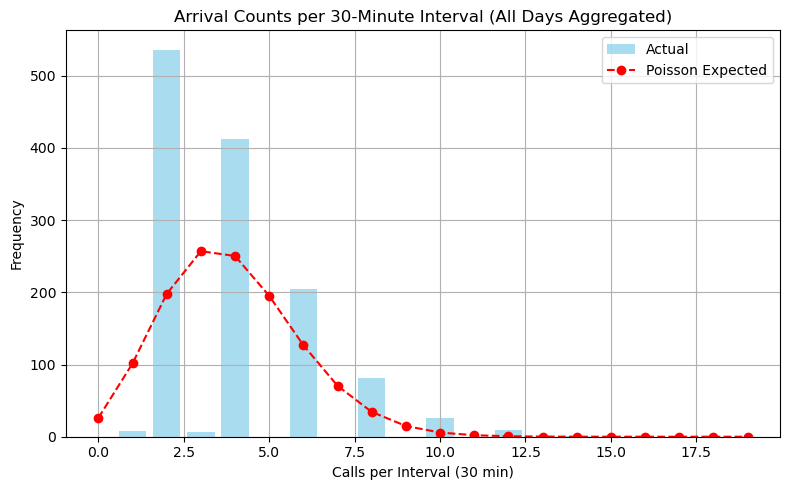

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, chisquare

df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")


# Clean column names and convert string to datetime
df.columns = df.columns.str.strip()

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S").dt.time

df['arrivetime'] = df.apply(lambda row: pd.Timestamp.combine(row['Date'], row['Time']), axis=1)



# === Step 2: Assign each call to its corresponding 30-minute interval (by day) ===
df['arrivetime_floor'] = df['arrivetime'].dt.floor('30min')  # Floor to the nearest 30 minutes
arrival_counts = df.groupby('arrivetime_floor').size()

print(df['arrivetime_floor'])

# === Step 3: Fit a Poisson distribution ===
lambda_hat = arrival_counts.mean()  # Estimated λ value
max_k = arrival_counts.max() + 5
k_vals = np.arange(max_k + 1)

# Theoretical frequencies (expected values)
expected_counts = poisson.pmf(k_vals, mu=lambda_hat) * len(arrival_counts)

# Observed frequencies
observed_counts, _ = np.histogram(arrival_counts, bins=np.arange(len(k_vals) + 1))

# Align lengths and adjust total sum
expected_counts = expected_counts[:len(observed_counts)]
expected_counts *= observed_counts.sum() / expected_counts.sum()

# === Step 4: Chi-squared test ===
chi2_stat, p_value_chi2 = chisquare(f_obs=observed_counts[:len(expected_counts)],
                                    f_exp=expected_counts)

# === Step 5: Print test results ===
print("\nChi-squared Test for Poisson Arrival Counts (per 30min block across days):")
print(f"Statistic: {chi2_stat:.2f}")
print(f"p-value: {p_value_chi2:.4f}")
if p_value_chi2 > 0.05:
    print("✅ Data likely follows a Poisson process")
else:
    print("❌ Data might not follow a Poisson process")

# === Step 6: Visualization ===
plt.figure(figsize=(8, 5))
plt.hist(arrival_counts, bins=range(arrival_counts.min(), arrival_counts.max() + 2),
         align='left', rwidth=0.8, alpha=0.7, color='skyblue', label='Actual')
plt.plot(k_vals, expected_counts, 'r--o', label='Poisson Expected')
plt.xlabel('Calls per Interval (30 min)')
plt.ylabel('Frequency')
plt.title('Arrival Counts per 30-Minute Interval (All Days Aggregated)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


KS test result: statistic = 0.2418, p-value = 0.0000
❌ Service times do not follow an exponential distribution.


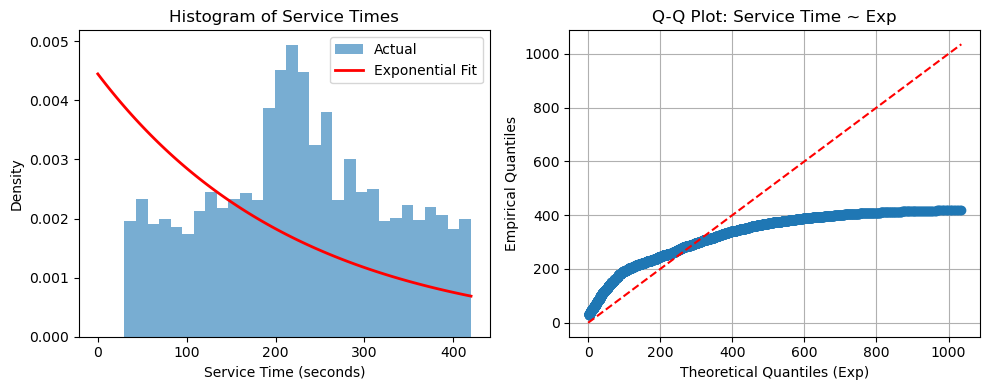

In [6]:
from scipy.stats import expon, kstest
import matplotlib.pyplot as plt
import numpy as np

# -----------------------
# Step 1: Prepare service time data
# -----------------------

# Copy the processed service time column (in seconds) from the dataframe
# This assumes the column 'AvgTalkDuration_seconds' has already been created earlier

df['servicetime'] = pd.to_timedelta(df['AvgTalkDuration']).dt.total_seconds()

service_times = df['servicetime'].dropna()  # Drop any missing values

# -----------------------
# Step 2: Estimate exponential distribution parameter
# -----------------------

# Estimate the mean of the service times (λ = 1/mean)
mean_service = service_times.mean()

# -----------------------
# Step 3: Perform Kolmogorov–Smirnov (K-S) test
# -----------------------

# Test if service times follow an exponential distribution with estimated mean
ks_stat, p_val = kstest(service_times, 'expon', args=(0, mean_service))

# Output the K-S test result
print(f"KS test result: statistic = {ks_stat:.4f}, p-value = {p_val:.4f}")
if p_val > 0.05:
    print("✅ Service times may follow an exponential distribution.")
else:
    print("❌ Service times do not follow an exponential distribution.")

# -----------------------
# Step 4: Visualization
# -----------------------

plt.figure(figsize=(10, 4))

# --- Left Plot: Histogram + Fitted Exponential Curve ---
plt.subplot(1, 2, 1)

# Plot histogram of observed service times
plt.hist(service_times, bins=30, density=True, alpha=0.6, label='Actual')

# Plot theoretical exponential PDF with fitted mean
x = np.linspace(0, service_times.max(), 100)
plt.plot(x, expon.pdf(x, scale=mean_service), 'r-', lw=2, label='Exponential Fit')

plt.xlabel("Service Time (seconds)")
plt.ylabel("Density")
plt.title("Histogram of Service Times")
plt.legend()

# --- Right Plot: Q-Q Plot ---
plt.subplot(1, 2, 2)

# Q-Q plot: compare observed quantiles to theoretical exponential quantiles
sorted_data = np.sort(service_times)
theoretical = expon.ppf(np.linspace(0.01, 0.99, len(sorted_data)), scale=mean_service)

# Plot empirical vs. theoretical quantiles
plt.plot(theoretical, sorted_data, 'o')
plt.plot([0, max(theoretical)], [0, max(theoretical)], 'r--', label='y = x')

plt.xlabel("Theoretical Quantiles (Exp)")
plt.ylabel("Empirical Quantiles")
plt.title("Q-Q Plot: Service Time ~ Exp")
plt.grid(True)

# Adjust layout
plt.tight_layout()
plt.show()


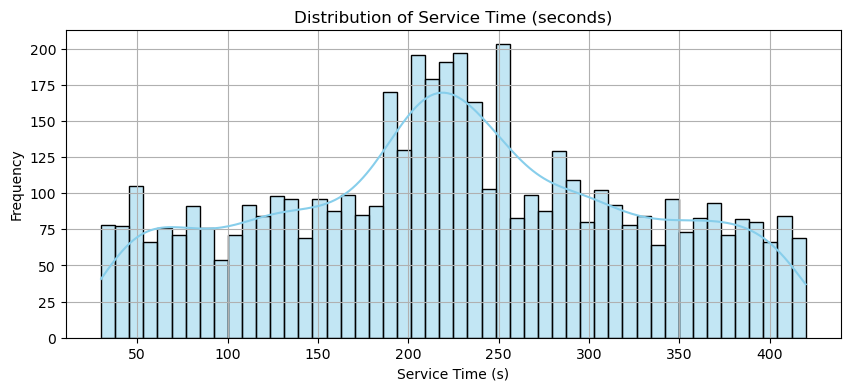

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 确保服务时间列存在（单位：秒）
df["service_sec"] = df["AvgTalkDuration"].apply(lambda x: duration_to_seconds(x))

plt.figure(figsize=(10, 4))
sns.histplot(df["service_sec"].dropna(), bins=50, kde=True, color='skyblue')
plt.title("Distribution of Service Time (seconds)")
plt.xlabel("Service Time (s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

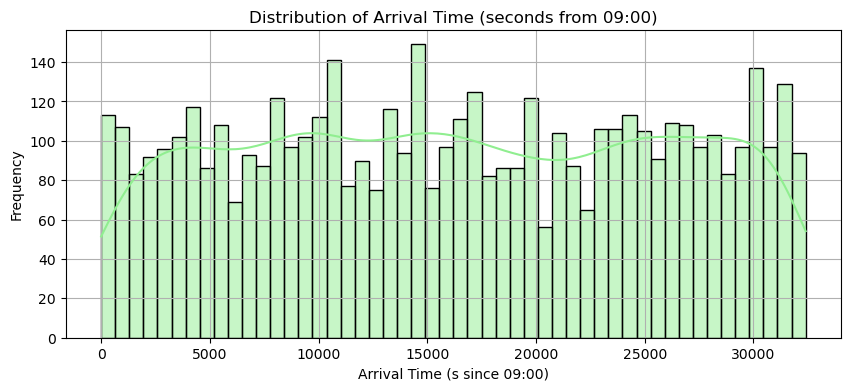

In [26]:
# 到达时间列应为 arrival_sec（相对于 09:00）
plt.figure(figsize=(10, 4))
sns.histplot(df["arrival_sec"].dropna(), bins=50, kde=True, color='lightgreen')
plt.title("Distribution of Arrival Time (seconds from 09:00)")
plt.xlabel("Arrival Time (s since 09:00)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


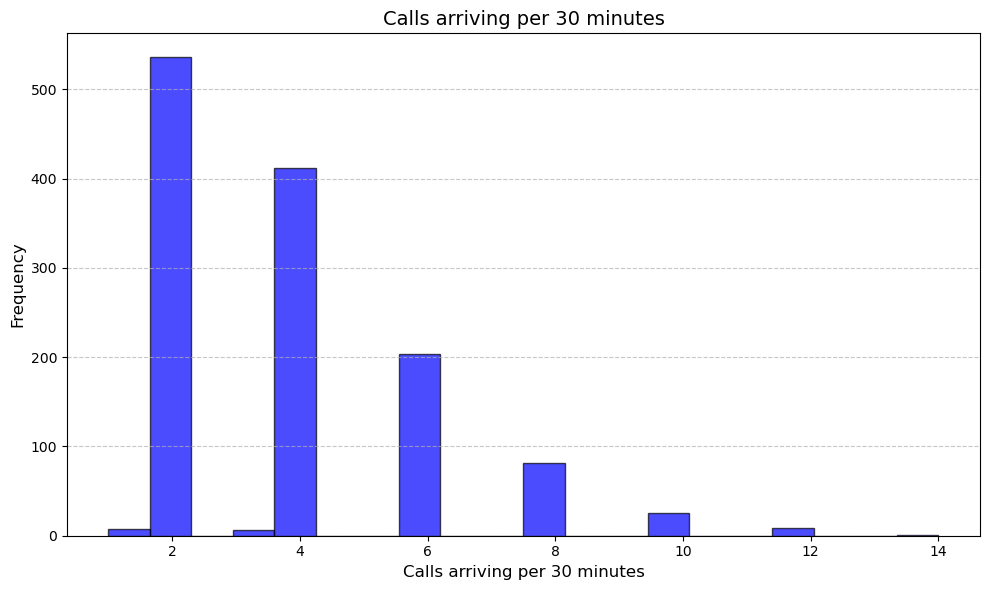

/var/folders/m8/z0s71_vs7glbsmd84zt1dx6r0000gn/T/ipykernel_41580/1232118916.py:38: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(arrival_counts, shade=True, color='blue')


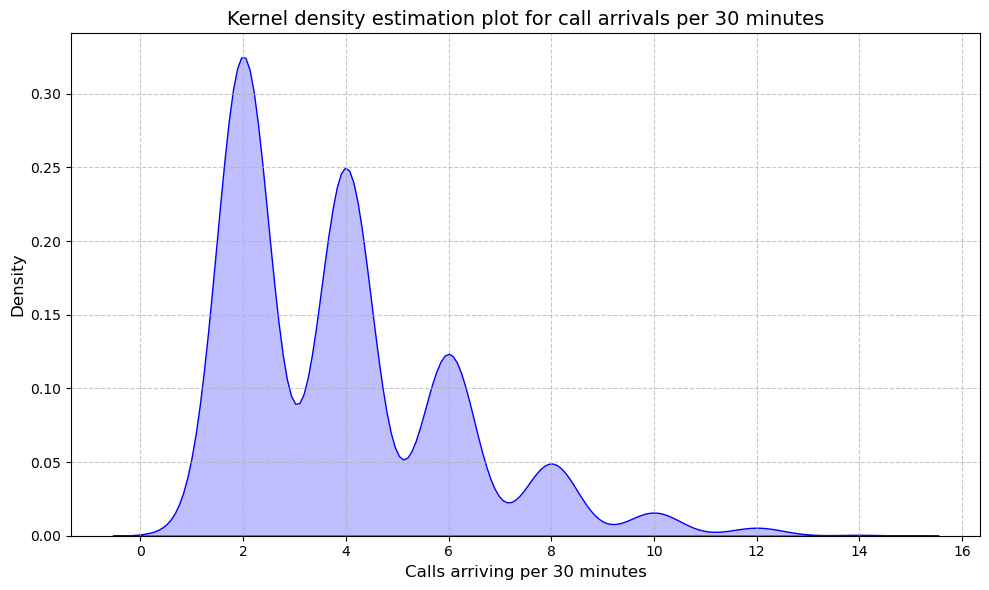

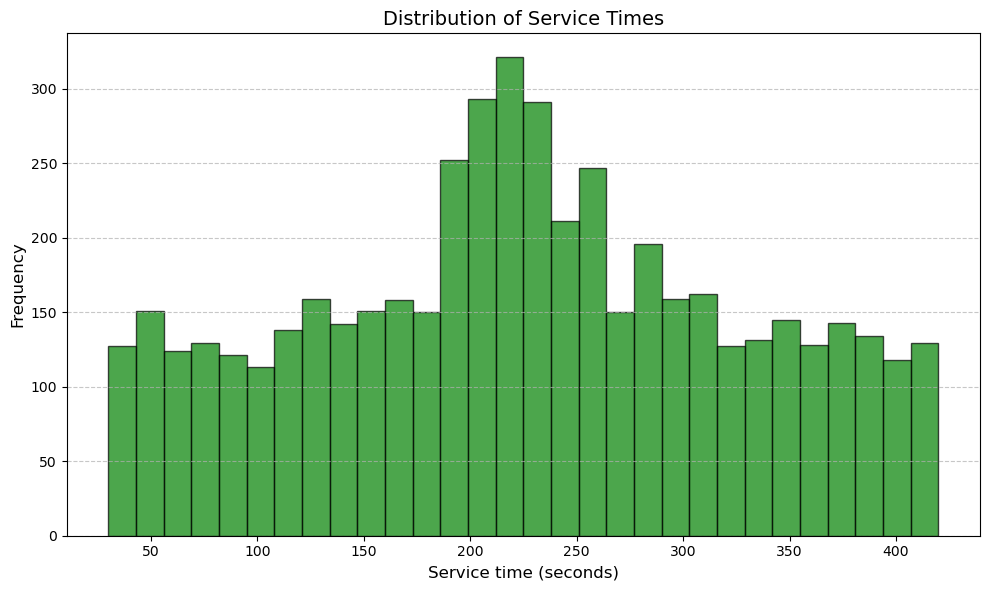

/var/folders/m8/z0s71_vs7glbsmd84zt1dx6r0000gn/T/ipykernel_41580/1232118916.py:69: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(service_times, shade=True, color='green')


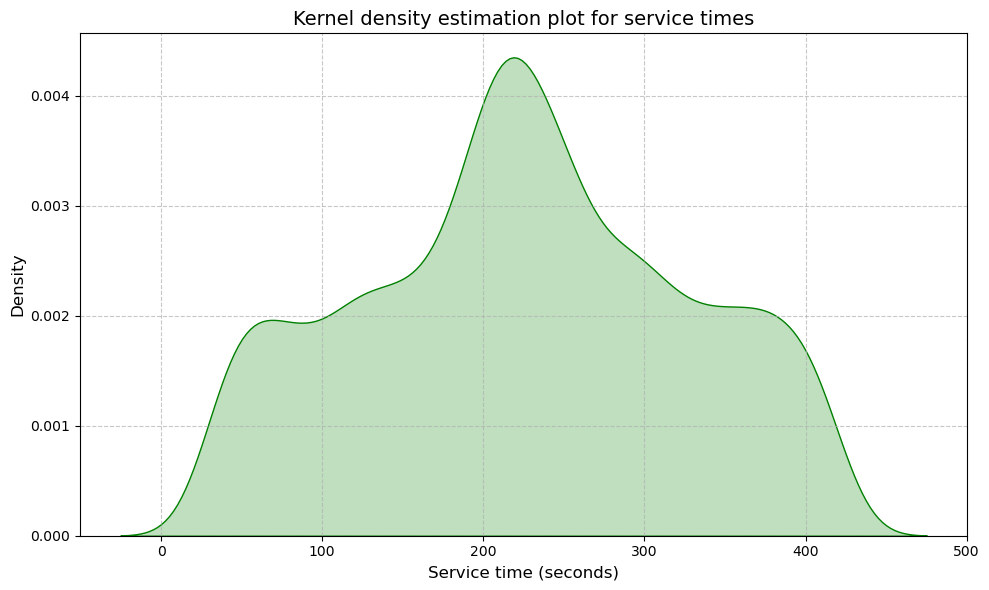

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Step 1: Read and preprocess the dataset ===
# Clean column names by stripping any extra whitespace
df.columns = df.columns.str.strip()

# If the 'arrivetime' column doesn't already exist, create it by combining 'Date' and 'Time'
if 'arrivetime' not in df.columns:
    df['arrivetime'] = pd.to_datetime(df['Date'].str.strip() + ' ' + df['Time'].str.strip())

# === Step 2: Compute the number of call arrivals per time interval ===
# Sort the dataframe by call arrival time
df = df.sort_values('arrivetime')

# Round down each arrival time to the nearest 30-minute block
df['arrivetime_interval'] = df['arrivetime'].dt.floor('30min')

# Count the number of calls in each 30-minute interval
arrival_counts = df.groupby('arrivetime_interval').size()

# === Step 3: Plot a histogram of arrivals per 30-minute interval ===
plt.figure(figsize=(10, 6))
plt.hist(arrival_counts, bins=20, alpha=0.7, color='blue', edgecolor='black')
plt.xlabel('Calls arriving per 30 minutes', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Calls arriving per 30 minutes', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === Step 4: Plot a KDE (Kernel Density Estimation) for arrival counts ===
plt.figure(figsize=(10, 6))
sns.kdeplot(arrival_counts, shade=True, color='blue')
plt.xlabel('Calls arriving per 30 minutes', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Kernel density estimation plot for call arrivals per 30 minutes', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === Step 5: Convert 'AvgTalkDuration' to numerical service time in seconds ===
# Convert from time string (e.g., "00:02:23") to seconds using timedelta
df['service_time_seconds'] = pd.to_timedelta(df['AvgTalkDuration']).dt.total_seconds()

# Drop missing values for service time
service_times = df['service_time_seconds'].dropna()

# === Step 6: Plot histogram of service times ===
plt.figure(figsize=(10, 6))
plt.hist(service_times, bins=30, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Service time (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Service Times', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# === Step 7: Plot KDE for service times ===
plt.figure(figsize=(10, 6))
sns.kdeplot(service_times, shade=True, color='green')
plt.xlabel('Service time (seconds)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Kernel density estimation plot for service times', fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


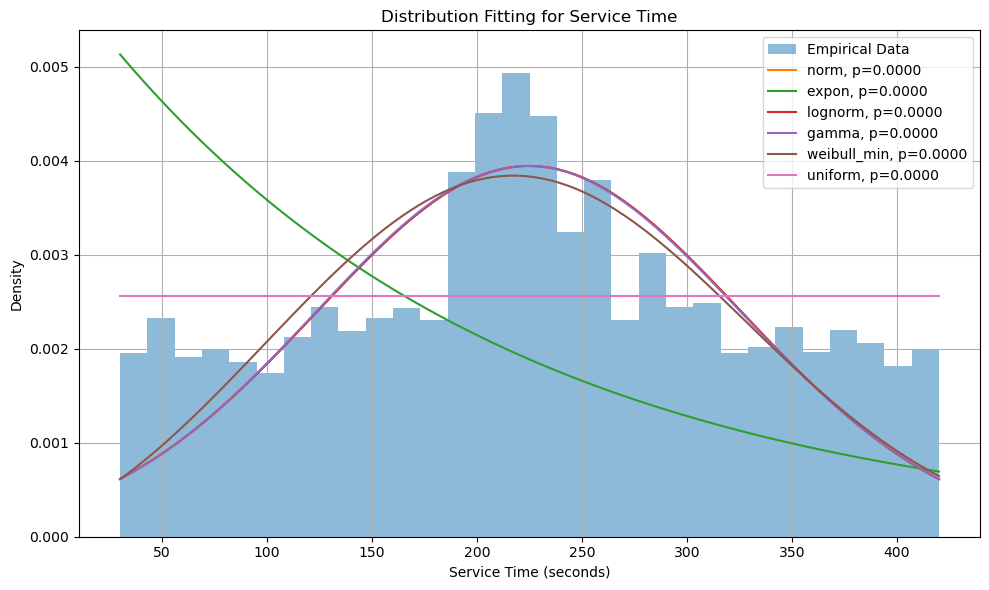

Best fit distributions (sorted by p-value):
gamma: p = 0.0000
lognorm: p = 0.0000
norm: p = 0.0000
weibull_min: p = 0.0000
uniform: p = 0.0000
expon: p = 0.0000


In [8]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Get service time data as a NumPy array, removing any missing values
data = service_times.dropna().values

# List of candidate distributions to test
distributions = ['norm', 'expon', 'lognorm', 'gamma', 'weibull_min', 'uniform']

# This list will store tuples of (distribution_name, p-value) for ranking
results = []

# Generate x values for plotting the fitted probability density functions (PDFs)
x = np.linspace(data.min(), data.max(), 100)

# Create the base histogram of the actual (empirical) service time data
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.5, label='Empirical Data')

# Loop through each distribution, fit it to the data, plot its PDF, and perform a KS test
for dist_name in distributions:
    dist = getattr(stats, dist_name)        # Get the distribution object from scipy.stats
    params = dist.fit(data)                 # Fit the distribution to the data to get optimal parameters
    pdf_fitted = dist.pdf(x, *params)       # Generate PDF values using fitted parameters
    D, p = stats.kstest(data, dist_name, args=params)  # Perform the Kolmogorov–Smirnov test
    results.append((dist_name, p))          # Save the result for later ranking
    plt.plot(x, pdf_fitted, label=f"{dist_name}, p={p:.4f}")  # Plot the PDF with p-value

# Plot formatting
plt.title("Distribution Fitting for Service Time")
plt.xlabel("Service Time (seconds)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Sort results by p-value (descending), higher p-value = better fit
results.sort(key=lambda tup: tup[1], reverse=True)

# Print sorted results
print("Best fit distributions (sorted by p-value):")
for name, p in results:
    print(f"{name}: p = {p:.4f}")


In [9]:
type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

# Calculate the number of Type1, Type2 calls
type1_count = df.loc[df["CallType"] == 1].shape[0]
type2_count = df.loc[df["CallType"] == 2].shape[0]

print(f"Total calls classified as Type1: {type1_count}")
print(f"Total calls classified as Type2: {type2_count}")
print(df)

Total calls classified as Type1: 2959
Total calls classified as Type2: 2041
     Call Id  Agent       Date      Time              Topic Answered (Y/N)  \
0     ID0001  Sarah 2021-01-01  09:12:58   Contract related              Y   
1     ID0002  Sarah 2021-01-01  09:12:58  Technical Support              Y   
2     ID0003  Sarah 2021-01-01  09:47:31   Contract related              Y   
3     ID0004  Sarah 2021-01-01  09:47:31   Contract related              Y   
4     ID0005  Sarah 2021-01-01  10:00:29    Payment related              Y   
...      ...    ...        ...       ...                ...            ...   
4995  ID4996  Sarah 2021-03-31  16:37:55    Payment related              Y   
4996  ID4997  Sarah 2021-03-31  16:45:07    Payment related              Y   
4997  ID4998  Sarah 2021-03-31  16:53:46    Payment related              Y   
4998  ID4999    Tom 2021-03-31  17:02:24          Streaming              Y   
4999  ID5000  Sarah 2021-03-31  17:39:50   Contract related       

### Baseline 

Total simulation days: 90
Example first 5 call records for one day: [(778.0, 1, 143), (778.0, 2, 242), (2851.0, 1, 131), (2851.0, 1, 37), (3629.0, 1, 60)]
Starting training for Robust Q-learning strategy...


Training Iterations: 100%|██████████| 1000/1000 [00:08<00:00, 123.34it/s]


Training complete. Sample Q-values:
State (1, 0, 1, 0): Q(wait)=-3267.19, Q(assign)=-10.00
State (0, 0, 1, 1): Q(wait)=0.00, Q(assign)=0.00
State (2, 0, 1, 0): Q(wait)=-4342.66, Q(assign)=-1428.70
State (3, 0, 1, 0): Q(wait)=-7706.56, Q(assign)=-3622.22
State (1, 0, 1, 1): Q(wait)=0.00, Q(assign)=0.00


Evaluating: 100%|██████████| 90/90 [00:00<00:00, 8649.63it/s]


FCFS average waiting time: 52.96 seconds
Robust Q-learning average waiting time: 106.38 seconds


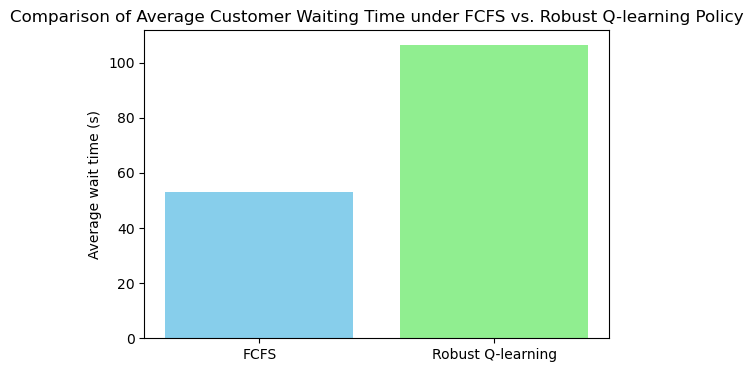

In [10]:
import pandas as pd
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from tqdm import tqdm   # for displaying progress bars
import heapq

# -----------------------
# 1. Data Loading and Preprocessing
# -----------------------
# Read the raw data (make sure Preprocessed_ModifiedCallCenterTwo.xlsx is in the current directory)
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

# Classify calls by topic: assume "Technical Support" and "Streaming" are type2, others are type1
type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

# Convert time field: convert the "Time" column to datetime, then compute seconds elapsed since 09:00:00
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()

# Filter calls within the 9 hours from 09:00 to 18:00 (i.e., 0 - 32400 seconds)
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= 32400)]

# Define a function to convert AvgTalkDuration from "HH:MM:SS" to seconds
def duration_to_seconds(dur):
    if isinstance(dur, str):
        h, m, s = map(int, dur.split(":"))
        return h * 3600 + m * 60 + s
    else:
        return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

# Group by date, with each day as a simulation episode
days_data = {}
for date, group in df.groupby("Date"):
    day_calls = group.sort_values("arrival_sec")
    # Each call record: (arrival_sec, CallType, service_sec)
    events = [(row["arrival_sec"], row["CallType"], row["service_sec"]) 
              for _, row in day_calls.iterrows()]
    if events:
        days_data[pd.to_datetime(date).date()] = events

print(f"Total simulation days: {len(days_data)}")
print(f"Example first 5 call records for one day: {list(days_data.values())[0][:5]}")

# -----------------------
# 2. Define the Simulation Environment Functions (FCFS and Robust Q-learning Strategies)
# -----------------------

def simulate_episode(events, policy="FCFS", Q_table=None, epsilon=0.0, M=50):
    """
    Simulate one day of call center operation
    events: List of events for the day, each element is (arrival_sec, call_type, service_sec)
    policy: "FCFS" or "RL"
    Q_table: If using the RL strategy, provide the Q-table dictionary
    epsilon: Exploration rate for epsilon-greedy (used only for the RL strategy)
    M: Maximum queue capacity
    Returns: total waiting time for the day, total number of calls served
    """
    # Queues: store type1 and type2 calls separately; each tuple is (arrival_time, service_time)
    q1 = []
    q2 = []
    # Server state: False indicates idle, True indicates busy
    b1_busy, b2_busy = False, False
    # Event heap: stores (finish_time, server, call_arrival_time)
    completions = []
    current_time = 0.0
    i = 0  # Index pointer for events

    total_wait = 0.0
    served = 0

    # Simulate events until the end of the work day (32400 seconds)
    while current_time < 32400:
        next_arrival = events[i][0] if i < len(events) else math.inf
        next_completion = completions[0][0] if completions else math.inf
        next_event = min(next_arrival, next_completion, 32400)
        # If next_event reaches the end-of-day, break to avoid popping from an empty heap
        if next_event == 32400:
            break
        current_time = next_event

        if current_time == next_arrival:
            # Arrival event
            arrival, call_type, svc_time = events[i]
            i += 1
            if call_type == 1:
                if not b1_busy:
                    # Server 1 idle, serve immediately
                    b1_busy = True
                    wait = 0.0
                    served += 1
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 1, current_time))
                elif not b2_busy:
                    # Server 1 busy, server 2 idle — decision point
                    if len(q1) + len(q2) < M:
                        q1.append((current_time, svc_time))
                        # Current state: number of waiting type1 and type2 calls and server statuses
                        state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                        if policy == "FCFS":
                            action = 1  # FCFS always serves immediately
                        elif policy == "RL" and Q_table is not None:
                            if random.random() < epsilon:
                                action = random.choice([0, 1])
                            else:
                                q_vals = Q_table.get(state, [0.0, 0.0])
                                action = int(np.argmax(q_vals))
                        else:
                            action = 1
                        if action == 1:
                            # Choose immediate service: remove from the queue
                            arr_time, svc_time_actual = q1.pop(0)
                            b2_busy = True
                            wait = current_time - arr_time
                            served += 1
                            total_wait += wait
                            finish = current_time + svc_time_actual
                            heapq.heappush(completions, (finish, 2, arr_time))
                        # If action is to wait, then keep the call in the queue
                    # If the queue is full, drop the call
                else:
                    # Both servers are busy
                    if len(q1) + len(q2) < M:
                        q1.append((current_time, svc_time))
            else:
                # Type2 call
                if not b2_busy:
                    b2_busy = True
                    wait = 0.0
                    served += 1
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 2, current_time))
                else:
                    if len(q1) + len(q2) < M:
                        q2.append((current_time, svc_time))
        else:
            # Completion event
            if completions:
                finish, server, call_arrival = heapq.heappop(completions)
            else:
                break
            if server == 1:
                b1_busy = False
            else:
                b2_busy = False
            # Assign waiting calls from the queue
            if not b1_busy and q1:
                arr_time, svc_time = q1.pop(0)
                b1_busy = True
                wait = current_time - arr_time
                served += 1
                total_wait += wait
                finish_new = current_time + svc_time
                heapq.heappush(completions, (finish_new, 1, arr_time))
            if not b2_busy:
                if q2:
                    arr_time, svc_time = q2.pop(0)
                    b2_busy = True
                    wait = current_time - arr_time
                    served += 1
                    total_wait += wait
                    finish_new = current_time + svc_time
                    heapq.heappush(completions, (finish_new, 2, arr_time))
                elif q1:
                    # For type1 calls, when server 2 is idle, decide based on the policy
                    state = (len(q1), len(q2), 1 if b1_busy else 0, 0)
                    if policy == "FCFS":
                        action = 1
                    elif policy == "RL" and Q_table is not None:
                        if random.random() < epsilon:
                            action = random.choice([0, 1])
                        else:
                            q_vals = Q_table.get(state, [0.0, 0.0])
                            action = int(np.argmax(q_vals))
                    else:
                        action = 1
                    if action == 1:
                        arr_time, svc_time = q1.pop(0)
                        b2_busy = True
                        wait = current_time - arr_time
                        served += 1
                        total_wait += wait
                        finish_new = current_time + svc_time
                        heapq.heappush(completions, (finish_new, 2, arr_time))
                    # Otherwise, do nothing and continue waiting
    return total_wait, served

# -----------------------
# 3. Training Based on the Robust Q-learning Strategy
# -----------------------
Q = {}

def get_Q_values(state):
    if state not in Q:
        Q[state] = [0.0, 0.0]
    return Q[state]

episodes = list(days_data.keys())   # Each day as an episode
num_iterations = 1000               # Number of training iterations
gamma = 0.95                        # Discount factor
alpha0 = 0.5                        # Initial learning rate
epsilon0 = 0.1                      # Initial epsilon exploration rate
decay_rate = 0.99                   # Decay rate for learning rate and epsilon
penalty = 10.0                      # Robust penalty applied for immediate service action

print("Starting training for Robust Q-learning strategy...")
for it in tqdm(range(num_iterations), desc="Training Iterations"):
    for day in episodes:
        events = days_data[day]
        events = sorted(events, key=lambda x: x[0])
        # Initialize environment
        q1 = []
        q2 = []
        b1_busy, b2_busy = False, False
        completions = []
        current_time = 0.0
        i = 0
        last_decision_time = 0.0
        # During simulation, update Q-values at each decision point (only when server 2 is idle and a type1 call is waiting)
        while current_time < 32400:
            next_arrival = events[i][0] if i < len(events) else math.inf
            next_completion = completions[0][0] if completions else math.inf
            next_event = min(next_arrival, next_completion, 32400)
            if next_event == 32400:
                break
            current_time = next_event

            if current_time == next_arrival:
                arrival, call_type, svc_time = events[i]
                i += 1
                if call_type == 1:
                    if not b1_busy:
                        b1_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 1, current_time))
                    elif not b2_busy:
                        if len(q1) + len(q2) < 50:
                            q1.append((current_time, svc_time))
                            state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                            if random.random() < epsilon0:
                                action = random.choice([0, 1])
                            else:
                                q_vals = get_Q_values(state)
                                action = int(np.argmax(q_vals))
                            if action == 1:
                                arr_time, svc_time_actual = q1.pop(0)
                                b2_busy = True
                                wait = current_time - arr_time
                                finish = current_time + svc_time_actual
                                heapq.heappush(completions, (finish, 2, arr_time))
                            reward = - (len(q1) + len(q2)) * (current_time - last_decision_time)
                            inst_reward = (- penalty) if action == 1 else 0.0
                            new_state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                            Q_vals = get_Q_values(state)
                            next_Q = get_Q_values(new_state)
                            target = (reward + inst_reward) + gamma * max(next_Q)
                            Q_vals[action] += alpha0 * (target - Q_vals[action])
                            Q[state] = Q_vals
                            last_decision_time = current_time
                    else:
                        if len(q1) + len(q2) < 50:
                            q1.append((current_time, svc_time))
                else:
                    if not b2_busy:
                        b2_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 2, current_time))
                    else:
                        if len(q1) + len(q2) < 50:
                            q2.append((current_time, svc_time))
            else:
                finish, server, call_arrival = heapq.heappop(completions)
                if server == 1:
                    b1_busy = False
                else:
                    b2_busy = False
                if not b1_busy and q1:
                    arr_time, svc_time = q1.pop(0)
                    b1_busy = True
                    finish = current_time + svc_time
                    heapq.heappush(completions, (finish, 1, arr_time))
                if not b2_busy:
                    if q2:
                        arr_time, svc_time = q2.pop(0)
                        b2_busy = True
                        finish = current_time + svc_time
                        heapq.heappush(completions, (finish, 2, arr_time))
                    elif q1:
                        state = (len(q1), len(q2), 1 if b1_busy else 0, 0)
                        if random.random() < epsilon0:
                            action = random.choice([0, 1])
                        else:
                            q_vals = get_Q_values(state)
                            action = int(np.argmax(q_vals))
                        if action == 1:
                            arr_time, svc_time = q1.pop(0)
                            b2_busy = True
                            finish = current_time + svc_time
                            heapq.heappush(completions, (finish, 2, arr_time))
                        reward = - (len(q1) + len(q2)) * (current_time - last_decision_time)
                        inst_reward = (- penalty) if action == 1 else 0.0
                        new_state = (len(q1), len(q2), 1 if b1_busy else 0, 1 if b2_busy else 0)
                        Q_vals = get_Q_values(state)
                        next_Q = get_Q_values(new_state)
                        target = (reward + inst_reward) + gamma * max(next_Q)
                        Q_vals[action] += alpha0 * (target - Q_vals[action])
                        Q[state] = Q_vals
                        last_decision_time = current_time
        # Decay the learning rate and epsilon
    alpha0 *= decay_rate
    epsilon0 *= decay_rate

print("Training complete. Sample Q-values:")
for s, vals in list(Q.items())[:5]:
    print(f"State {s}: Q(wait)={vals[0]:.2f}, Q(assign)={vals[1]:.2f}")

policy_Q = {}
for state, q_vals in Q.items():
    policy_Q[state] = int(np.argmax(q_vals))

# -----------------------
# 4. Performance Evaluation and Visual Comparison
# -----------------------
total_wait_fcfs = 0.0
total_served_fcfs = 0
total_wait_rl = 0.0
total_served_rl = 0

for day in tqdm(list(days_data.keys()), desc="Evaluating"):
    events = days_data[day]
    wait_fcfs, served_fcfs = simulate_episode(events, policy="FCFS", M=50)
    total_wait_fcfs += wait_fcfs
    total_served_fcfs += served_fcfs
    wait_rl, served_rl_day = simulate_episode(events, policy="RL", Q_table=policy_Q, epsilon=0.0, M=50)
    total_wait_rl += wait_rl
    total_served_rl += served_rl_day

avg_wait_fcfs = total_wait_fcfs / total_served_fcfs if total_served_fcfs > 0 else 0
avg_wait_rl = total_wait_rl / total_served_rl if total_served_rl > 0 else 0

print(f"FCFS average waiting time: {avg_wait_fcfs:.2f} seconds")
print(f"Robust Q-learning average waiting time: {avg_wait_rl:.2f} seconds")

plt.figure(figsize=(6, 4))
policies = ["FCFS", "Robust Q-learning"]
avg_waits = [avg_wait_fcfs, avg_wait_rl]
colors = ["skyblue", "lightgreen"]
plt.bar(policies, avg_waits, color=colors)
plt.ylabel("Average wait time (s)")
plt.title("Comparison of Average Customer Waiting Time under FCFS vs. Robust Q-learning Policy")
plt.show()

# print(df)


Calculated median service time (for imputation): 223.00 seconds
Loaded 90 days  |  sample → 2021-01-01

=== PPO training started ===


/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


=== PPO training finished ===



Eval-PPO: 100%|██████████| 90/90 [00:00<00:00, 364.78it/s]


PPO  - Avg wait = 94.97 s


Eval-FCFS: 100%|██████████| 90/90 [00:00<00:00, 24738.67it/s]


FCFS - Avg wait = 52.96 s   (queue=50)


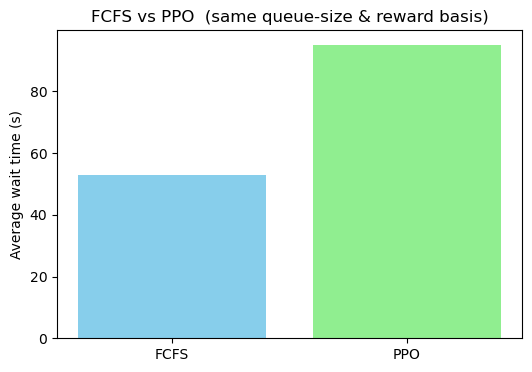

In [42]:
# =========================================
# Call-centre PPO vs FCFS   (Revised 2025-04-29)
# =========================================
import pandas as pd
import numpy as np
import math, random, heapq
import matplotlib.pyplot as plt
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- 0. Global hyper-params ----------
MAX_QUEUE  = 50          # 与第 2 份脚本保持一致
PENALTY    = 2.0         # 等同于 Q-learning 脚本中的 penalty
WORK_END   = 32_400      # 09:00-18:00

# ---------- 1. Data loading / preprocessing ----------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

# 1. 修改 duration_to_seconds 函数
def duration_to_seconds(dur):
    if isinstance(dur, str):
        try:
            h, m, s = map(int, dur.split(":"))
            return h * 3600 + m * 60 + s
        except:
             # 如果格式错误或不是字符串，返回 NaN
             return np.nan 
    # 对于已经是 NaN 或其他非字符串类型，也返回 NaN
    return np.nan 

# 应用修改后的函数，生成带有 NaN 的原始服务时长列
df["service_sec_raw"] = df["AvgTalkDuration"].apply(duration_to_seconds)

# 2. 计算中位数并进行插补
# 计算非 NaN 值的服务时长的中位数
median_service_sec = df["service_sec_raw"].median()
print(f"Calculated median service time (for imputation): {median_service_sec:.2f} seconds")

# 使用计算出的中位数填充 service_sec_raw 中的 NaN 值，得到最终的 service_sec 列
df["service_sec"] = df["service_sec_raw"].fillna(median_service_sec)

# （可选）确保服务时长非负
df["service_sec"] = df["service_sec"].apply(lambda x: max(0, x))


days_data = {}
for date, g in df.groupby("Date"):
    calls = [(row["arrival_sec"], row["CallType"], row["service_sec"])
             for _, row in g.sort_values("arrival_sec").iterrows()]
    if calls:
        days_data[pd.to_datetime(date).date()] = calls

print(f"Loaded {len(days_data)} days  |  sample → {list(days_data.keys())[0]}")

# ---------- 2. Custom Gym environment ----------
class CallCenterEnv(gym.Env):
    """
    Action: 0 = 等待 / 不把 Type-1 分给 Server-2
            1 = 把队首 Type-1 分给 Server-2
    Reward: 若 action=1 且成功分配，则 -wait - PENALTY
            其余情况 0
    """
    metadata = {"render.modes": []}

    def __init__(self, events, max_queue=MAX_QUEUE):
        super().__init__()
        self.events     = events
        self.max_queue  = max_queue
        self.action_space      = spaces.Discrete(2)
        # (len(q1), len(q2), b1_busy, b2_busy)
        self.observation_space = spaces.MultiDiscrete(
            [max_queue+1, max_queue+1, 2, 2]
        )
        self.reset()

    # ---- helpers ----
    def _state(self):
        return np.array(
            [len(self.q1), len(self.q2),
             int(self.b1_busy), int(self.b2_busy)],
            dtype=np.int32
        )

    # ---- core API ----
    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []                 # completion heap
        self.t = 0.0
        self.i = 0                     # index in self.events
        self.total_wait = 0.0
        return self._state()

    def step(self, action):
        """Let the sim run until next ‘decision point’ or end-of-day."""
        reward = 0.0
        done = False

        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0]       if self.comp else math.inf
            nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt_evt == WORK_END:
                done = True
                break
            self.t = nxt_evt

            # ----- arrival -----
            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:  # type-1
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 1, arr))
                    elif not self.b2_busy:
                        # decision point ─ Server-2 idle
                        if action == 1:
                            # 服务立即开始，计算等待
                            wait = 0.0                # arrived just now
                            reward = -wait - PENALTY
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+svc, 2, arr))
                        else:
                            # 入队
                            if len(self.q1)+len(self.q2) < self.max_queue:
                                self.q1.append((arr, svc))
                        break  # 一个决策完成，退出 while 并返回
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q1.append((arr, svc))
                else:         # type-2
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q2.append((arr, svc))
            # ----- completion -----
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False
                # server-1 先拉队首 type-1
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t+s, 1, a))
                # server-2：先 type-2，再看是否需要决策
                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+s, 2, a))
                    elif self.q1:
                        # 决策点：是否把队首 type-1 分给 server-2
                        if action == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            reward = -wait - PENALTY
                            self.total_wait += wait
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+s, 2, a))
                        # 无论 action 如何，都需返回给 PPO
                        break
        return self._state(), reward, done, {}

# ---------- 3. Create vectorised env & train PPO ----------
vec_env = DummyVecEnv([lambda ev=ev: CallCenterEnv(ev)
                       for ev in list(days_data.values())[:5]])

model = PPO("MlpPolicy", vec_env, verbose=0)
print("\n=== PPO training started ===")
model.learn(total_timesteps=100_000)
print("=== PPO training finished ===\n")

# ---------- 4. Evaluate PPO policy ----------
def run_policy(events, model):
    env = CallCenterEnv(events)
    obs = env.reset()
    done = False
    while not done:
        action, _ = model.predict(obs)
        obs, _, done, _ = env.step(action)
    return env.total_wait, len(events)

tot_wait_ppo = tot_calls_ppo = 0
for d, ev in tqdm(days_data.items(), desc="Eval-PPO"):
    w, n = run_policy(ev, model)
    tot_wait_ppo  += w
    tot_calls_ppo += n
avg_wait_ppo = tot_wait_ppo / tot_calls_ppo
print(f"PPO  - Avg wait = {avg_wait_ppo:.2f} s")

# ---------- 5. FCFS baseline (same as script-2) ----------
def simulate_fcfs(events, max_queue=MAX_QUEUE):
    q1, q2 = [], []
    b1_busy = b2_busy = False
    comp = []
    time, i = 0.0, 0
    wait_sum = served = 0

    while time < WORK_END:
        nxt_arr = events[i][0] if i < len(events) else math.inf
        nxt_cmp = comp[0][0]    if comp else math.inf
        nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
        if nxt_evt == WORK_END:
            break
        time = nxt_evt

        # ----- arrival -----
        if time == nxt_arr:
            arr, typ, svc = events[i]
            i += 1
            if typ == 1:
                if not b1_busy:
                    b1_busy = True
                    heapq.heappush(comp, (time+svc, 1, arr))
                    served += 1
                elif not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q1.append((arr, svc))
            else:  # type-2
                if not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q2.append((arr, svc))
        # ----- completion -----
        else:
            fin, srv, arr_time = heapq.heappop(comp)
            if srv == 1:
                b1_busy = False
            else:
                b2_busy = False
            # server-1
            if not b1_busy and q1:
                a, s = q1.pop(0)
                wait_sum += time - a
                served += 1
                b1_busy = True
                heapq.heappush(comp, (time+s, 1, a))
            # server-2
            if not b2_busy:
                if q2:
                    a, s = q2.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
                elif q1:
                    a, s = q1.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
    return wait_sum, served

tot_wait_fcfs = tot_serv_fcfs = 0
for ev in tqdm(days_data.values(), desc="Eval-FCFS"):
    w, n = simulate_fcfs(ev)
    tot_wait_fcfs += w
    tot_serv_fcfs += n
avg_wait_fcfs = tot_wait_fcfs / tot_serv_fcfs
print(f"FCFS - Avg wait = {avg_wait_fcfs:.2f} s   (queue={MAX_QUEUE})")

# ---------- 6. Visual comparison ----------
plt.figure(figsize=(6,4))
plt.bar(["FCFS", "PPO"], [avg_wait_fcfs, avg_wait_ppo],
        color=["skyblue", "lightgreen"])
plt.ylabel("Average wait time (s)")
plt.title("FCFS vs PPO  (same queue-size & reward basis)")
plt.show()


### HyperParameter Tuning


In [ ]:
import pandas as pd
import numpy as np
import math, random, heapq
import matplotlib.pyplot as plt
from tqdm import tqdm
import itertools

# -------------------------------
# 数据加载与预处理
# -------------------------------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= 32400)]

def duration_to_seconds(dur):
    if isinstance(dur, str):
        h, m, s = map(int, dur.split(":"))
        return h * 3600 + m * 60 + s
    return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

days_data = {}
for date, group in df.groupby("Date"):
    events = [(row["arrival_sec"], row["CallType"], row["service_sec"])
              for _, row in group.sort_values("arrival_sec").iterrows()]
    if events:
        days_data[pd.to_datetime(date).date()] = events

episodes = list(days_data.keys())[:5]  # 为节省时间，只用前5天训练

# -------------------------------
# 奖励函数定义
# -------------------------------
def compute_reward(rtype, action, wait, idle_servers, penalty, qlen):
    if rtype == "R1":
        return -wait - penalty if action == 1 else -0.05 * idle_servers
    elif rtype == "R2":
        if wait > 120:
            return -2.0 * (wait - 120)
        elif action == 1:
            return -0.5 * wait
        else:
            return 0
    elif rtype == "R3":
        if action == 1:
            return -wait - penalty if wait > 0 else -0.5 * penalty
        else:
            return -0.1 if qlen > 0 else +0.1
    else:
        return 0

# -------------------------------
# 超参数组合
# -------------------------------
param_grid = {
    "gamma": [0.85, 0.90, 0.95, 0.99],                   # 更宽的折扣因子
    "learning_rate": [0.1, 0.3, 0.5, 0.7],                # 更广的学习率
    "epsilon0": [0.01, 0.05, 0.1, 0.2],                   # 更宽的探索率
    "penalty": [1.0, 5.0, 10.0, 20.0],                    # 更灵活的惩罚强度
    "rtype": ["R1", "R2", "R3"]                           # 三种奖励函数
}

param_combinations = list(itertools.product(*param_grid.values()))

training_iterations = 30
results = []

for combo in tqdm(param_combinations, desc="Hyperparameter Search"):
    gamma, learning_rate, epsilon0, penalty, rtype = combo
    Q = {}
    update_count = 0  # 👈 新增：统计 Q 值更新次数

    def get_Q_values(state):
        if state not in Q:
            Q[state] = [0.0, 0.0]
        return Q[state]

    for _ in range(training_iterations):
        for day in episodes:
            events = days_data[day]
            events = sorted(events, key=lambda x: x[0])
            q1, q2 = [], []
            b1_busy, b2_busy = False, False
            completions = []
            current_time = 0.0
            i = 0
            last_decision_time = 0.0

            while current_time < 32400:
                next_arrival = events[i][0] if i < len(events) else math.inf
                next_completion = completions[0][0] if completions else math.inf
                current_time = min(next_arrival, next_completion, 32400)
                if current_time == 32400:
                    break

                if current_time == next_arrival:
                    arrival, call_type, svc_time = events[i]
                    i += 1
                    if call_type == 1:
                        if not b1_busy:
                            b1_busy = True
                            heapq.heappush(completions, (current_time + svc_time, 1, current_time))
                        elif not b2_busy:
                            if len(q1) + len(q2) < 50:
                                q1.append((current_time, svc_time))
                                state = (len(q1), len(q2), 1, 1)
                                if random.random() < epsilon0:
                                    action = random.choice([0, 1])
                                else:
                                    action = int(np.argmax(get_Q_values(state)))
                                if action == 1:
                                    arr_time, svc_time_actual = q1.pop(0)
                                    b2_busy = True
                                    wait = current_time - arr_time
                                    reward = compute_reward(rtype, action, wait, 1, penalty, len(q1)+len(q2))
                                    heapq.heappush(completions, (current_time + svc_time_actual, 2, arr_time))
                                    new_state = (len(q1), len(q2), 1, 1)
                                    Qs = get_Q_values(state)
                                    next_Q = get_Q_values(new_state)
                                    Qs[action] += learning_rate * ((reward + gamma * max(next_Q)) - Qs[action])
                                    Q[state] = Qs
                                    update_count += 1  # 👈 更新计数
                                    last_decision_time = current_time
                        else:
                            if len(q1) + len(q2) < 50:
                                q1.append((current_time, svc_time))
                    else:
                        if not b2_busy:
                            b2_busy = True
                            heapq.heappush(completions, (current_time + svc_time, 2, current_time))
                        else:
                            if len(q1) + len(q2) < 50:
                                q2.append((current_time, svc_time))
                else:
                    finish, server, call_arrival = heapq.heappop(completions)
                    if server == 1:
                        b1_busy = False
                    else:
                        b2_busy = False
                    if not b1_busy and q1:
                        arr_time, svc_time = q1.pop(0)
                        b1_busy = True
                        heapq.heappush(completions, (current_time + svc_time, 1, arr_time))
                    if not b2_busy:
                        if q2:
                            arr_time, svc_time = q2.pop(0)
                            b2_busy = True
                            heapq.heappush(completions, (current_time + svc_time, 2, arr_time))
                        elif q1:
                            state = (len(q1), len(q2), 1 if b1_busy else 0, 0)
                            if random.random() < epsilon0:
                                action = random.choice([0, 1])
                            else:
                                action = int(np.argmax(get_Q_values(state)))
                            if action == 1:
                                arr_time, svc_time = q1.pop(0)
                                b2_busy = True
                                wait = current_time - arr_time
                                reward = compute_reward(rtype, action, wait, 1, penalty, len(q1)+len(q2))
                                heapq.heappush(completions, (current_time + svc_time, 2, arr_time))
                                new_state = (len(q1), len(q2), 1 if b1_busy else 0, 1)
                                Qs = get_Q_values(state)
                                next_Q = get_Q_values(new_state)
                                Qs[action] += learning_rate * ((reward + gamma * max(next_Q)) - Qs[action])
                                Q[state] = Qs
                                update_count += 1
                                last_decision_time = current_time

    # # ⚠️ 如果没有更新，跳过此组合，避免伪结果
    # if update_count == 0:
    #     print(f"No Q updates for combo {combo}, skipping.")
    #     continue
    # else:
    #     print(f"Combo {combo} finished with {update_count} Q-updates.")

    # 使用Q策略评估策略效果
    policy_Q = {s: int(np.argmax(qvals)) for s, qvals in Q.items()}

    total_wait, total_served = 0.0, 0
    for day in episodes:
        events = days_data[day]
        q1, q2 = [], []
        b1_busy, b2_busy = False, False
        completions = []
        current_time = 0.0
        i = 0

        while current_time < 32400:
            next_arrival = events[i][0] if i < len(events) else math.inf
            next_completion = completions[0][0] if completions else math.inf
            current_time = min(next_arrival, next_completion, 32400)
            if current_time == 32400:
                break

            if current_time == next_arrival:
                arrival, call_type, svc_time = events[i]
                i += 1
                if call_type == 1:
                    if not b1_busy:
                        b1_busy = True
                        heapq.heappush(completions, (current_time + svc_time, 1, current_time))
                        total_served += 1
                    elif not b2_busy:
                        state = (len(q1), len(q2), 1, 0)
                        action = policy_Q.get(state, 1)
                        if action == 1:
                            b2_busy = True
                            total_served += 1
                            total_wait += 0
                            heapq.heappush(completions, (current_time + svc_time, 2, current_time))
                        else:
                            q1.append((current_time, svc_time))
                    else:
                        q1.append((current_time, svc_time))
                else:
                    if not b2_busy:
                        b2_busy = True
                        heapq.heappush(completions, (current_time + svc_time, 2, current_time))
                        total_served += 1
                    else:
                        q2.append((current_time, svc_time))
            else:
                finish, server, call_arrival = heapq.heappop(completions)
                if server == 1:
                    b1_busy = False
                else:
                    b2_busy = False
                if not b1_busy and q1:
                    arr_time, svc_time = q1.pop(0)
                    total_wait += current_time - arr_time
                    total_served += 1
                    b1_busy = True
                    heapq.heappush(completions, (current_time + svc_time, 1, arr_time))
                if not b2_busy:
                    if q2:
                        arr_time, svc_time = q2.pop(0)
                        total_wait += current_time - arr_time
                        total_served += 1
                        b2_busy = True
                        heapq.heappush(completions, (current_time + svc_time, 2, arr_time))
                    elif q1:
                        arr_time, svc_time = q1.pop(0)
                        total_wait += current_time - arr_time
                        total_served += 1
                        b2_busy = True
                        heapq.heappush(completions, (current_time + svc_time, 2, arr_time))

    avg_wait = total_wait / total_served if total_served > 0 else 0
    results.append((avg_wait, gamma, alpha0, epsilon0, penalty, rtype))

# 输出 top 10 表现最好的配置
results.sort()
print("\nTop 10 parameter combinations (lowest average waiting time):")
for i, (wait, gamma, alpha0, epsilon0, penalty, rtype) in enumerate(results[:10]):
    print(f"{i+1}. Wait: {wait:.2f}s | gamma={gamma}, alpha={alpha0}, epsilon={epsilon0}, penalty={penalty}, rtype={rtype}")


Hyperparameter Search: 100%|██████████| 768/768 [00:10<00:00, 69.89it/s]


Top 10 parameter combinations (lowest average waiting time):
1. Wait: 82.79s | gamma=0.85, alpha=0.1, epsilon=0.01, penalty=1.0, rtype=R1


In [41]:
# =========================================
#  Grid Search: reward / steps / penalty / lr   (PPO)
# =========================================
import itertools, math, random, heapq, time
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- 0. Global constants ----------
MAX_QUEUE = 50
WORK_END  = 32_400          # 09:00-18:00
GAMMA     = 0.99            # 折扣因子固定
CLIP      = 0.2             # clip_range 固定

# ---------- 1. Load & preprocess data ----------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

def duration_to_seconds(dur):
    if isinstance(dur, str):
        try:
            h, m, s = map(int, dur.split(":"))
            return h*3600 + m*60 + s
        except ValueError:
            return np.nan
    return np.nan

df["service_sec_raw"] = df["AvgTalkDuration"].apply(duration_to_seconds)
median_svc = df["service_sec_raw"].median()
df["service_sec"] = df["service_sec_raw"].fillna(median_svc).clip(lower=0)

# 每天 = 一个 episode
days_data = {
    pd.to_datetime(d).date():
        [(r["arrival_sec"], r["CallType"], r["service_sec"])
         for _, r in g.sort_values("arrival_sec").iterrows()]
    for d, g in df.groupby("Date")
}
print(f"Loaded {len(days_data)} days")

# ---------- 2. 超参数网格 ----------
param_grid = {
    "WAIT_WEIGHT"  : [0.8, 1.0, 1.2],
    "PENALTY"      : [0, 0.5, 5],
    "TOTAL_STEPS"  : [40_000, 60_000, 80_000],
    "learning_rate": [1e-5, 1e-7, 1e-8, 1e-9]
}
combo_list = list(itertools.product(*param_grid.values()))
print(f"Total combos: {len(combo_list)}")

# ---------- 3. 自定义环境 ----------
class CallCenterEnv(gym.Env):
    metadata = {"render.modes": []}

    def __init__(self, events, wait_w=1.0, penalty=2.0):
        super().__init__()
        self.events, self.wait_w, self.penalty = events, wait_w, penalty
        self.action_space = spaces.Discrete(2)          # 0=保守, 1=允许 S2 抢占 type-1
        self.observation_space = spaces.MultiDiscrete([MAX_QUEUE+1]*2 + [2, 2])
        self.reset()

    def _state(self):
        return np.array([
            len(self.q1), len(self.q2),
            int(self.b1_busy), int(self.b2_busy)
        ], np.int32)

    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []                 # (finish_time, server_id, arrival_time)
        self.t = 0.0
        self.i = 0
        self.total_wait = 0.0
        return self._state()

    def step(self, act):
        rew, done = 0.0, False
        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0]        if self.comp else math.inf
            nxt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt == WORK_END:
                done = True
                break
            self.t = nxt

            # ---------- arrival ----------
            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:  # ----- type-1 arrival
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 1, arr))
                    elif not self.b2_busy:
                        if act == 1:  # 抢占
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+svc, 2, arr))
                            rew -= self.wait_w*0 + self.penalty
                        else:         # 入队
                            if len(self.q1) + len(self.q2) < MAX_QUEUE:
                                self.q1.append((arr, svc))
                        break
                    else:             # 两台都忙
                        if len(self.q1) + len(self.q2) < MAX_QUEUE:
                            self.q1.append((arr, svc))

                else:  # ---------- type-2 arrival
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    elif len(self.q1) + len(self.q2) < MAX_QUEUE:
                        self.q2.append((arr, svc))

            # ---------- completion ----------
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False

                # 尝试从队列派单
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t+s, 1, a))

                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+s, 2, a))
                    elif self.q1:
                        if act == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            self.total_wait += wait
                            rew -= self.wait_w*wait + self.penalty
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+s, 2, a))
                        break

        return self._state(), rew, done, {}

# ---------- 4. 训练 + 评估 ----------
def train_and_eval(events_list, ww, pen, lr, steps):
    # 前 5 天做训练
    vec_env = DummyVecEnv([
        lambda ev=e, w=ww, p=pen: CallCenterEnv(ev, w, p)
        for e in events_list[:5]
    ])

    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=0,
        gamma=GAMMA,
        learning_rate=lr,
        clip_range=CLIP
    )
    model.learn(total_timesteps=steps)

    # 在全部天数上评估
    tot_w, tot_n = 0.0, 0
    for ev in events_list:
        env = CallCenterEnv(ev, ww, pen)
        obs, done = env.reset(), False
        while not done:
            a, _ = model.predict(obs)
            obs, _, done, _ = env.step(a)
        tot_w += env.total_wait
        tot_n += len(ev)
    return tot_w / tot_n  # 平均等待秒数

# ---------- 5. Grid search ----------
results = []
keys = list(param_grid.keys())
start = time.time()

for vals in tqdm(combo_list, desc="Grid"):
    params = dict(zip(keys, vals))
    avg_wait = train_and_eval(
        list(days_data.values()),
        params["WAIT_WEIGHT"],
        params["PENALTY"],
        params["learning_rate"],
        params["TOTAL_STEPS"]
    )
    params["avg_wait"] = avg_wait
    results.append(params)
    print(f"→ {params}")

print(f"\nGrid search finished in {(time.time()-start)/60:.1f} min")

# ---------- 6. 排序展示 ----------
results.sort(key=lambda x: x["avg_wait"])
print("\n=== Top 10 combos ===")
for r in results[:10]:
    print(r)


Loaded 90 days
Total combos: 108


Grid:   0%|          | 0/108 [00:00<?, ?it/s]/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
Grid:   1%|          | 1/108 [00:08<14:35,  8.19s/it]

→ {'WAIT_WEIGHT': 0.8, 'PENALTY': 0, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-05, 'avg_wait': 81.691}


Grid:   2%|▏         | 2/108 [00:16<14:12,  8.04s/it]

→ {'WAIT_WEIGHT': 0.8, 'PENALTY': 0, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-07, 'avg_wait': 71.8894}


...

→ {'WAIT_WEIGHT': 1.2, 'PENALTY': 5, 'TOTAL_STEPS': 80000, 'learning_rate': 1e-07, 'avg_wait': 73.726}


Grid:  99%|█████████▉| 107/108 [25:25<00:18, 18.74s/it]

→ {'WAIT_WEIGHT': 1.2, 'PENALTY': 5, 'TOTAL_STEPS': 80000, 'learning_rate': 1e-08, 'avg_wait': 71.7452}


Grid: 100%|██████████| 108/108 [25:45<00:00, 14.31s/it]

→ {'WAIT_WEIGHT': 1.2, 'PENALTY': 5, 'TOTAL_STEPS': 80000, 'learning_rate': 1e-09, 'avg_wait': 73.3262}

Grid search finished in 25.8 min

=== Top 10 combos ===
{'WAIT_WEIGHT': 1.2, 'PENALTY': 0.5, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-07, 'avg_wait': 70.131}
{'WAIT_WEIGHT': 0.8, 'PENALTY': 5, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-07, 'avg_wait': 70.1662}
{'WAIT_WEIGHT': 0.8, 'PENALTY': 0, 'TOTAL_STEPS': 80000, 'learning_rate': 1e-08, 'avg_wait': 70.448}
{'WAIT_WEIGHT': 0.8, 'PENALTY': 0.5, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-08, 'avg_wait': 70.513}
{'WAIT_WEIGHT': 1.2, 'PENALTY': 5, 'TOTAL_STEPS': 40000, 'learning_rate': 1e-07, 'avg_wait': 70.77}
{'WAIT_WEIGHT': 1.0, 'PENALTY': 0.5, 'TOTAL_STEPS': 80000, 'learning_rate': 1e-08, 'avg_wait': 70.9284}
{'WAIT_WEIGHT': 0.8, 'PENALTY': 0.5, 'TOTAL_STEPS': 60000, 'learning_rate': 1e-09, 'avg_wait': 71.0594}
{'WAIT_WEIGHT': 0.8, 'PENALTY': 0, 'TOTAL_STEPS': 60000, 'learning_rate': 1e-09, 'avg_wait': 71.0998}
{'WAIT_WEIGHT': 0.8,

In [14]:
import pandas as pd
import numpy as np
import math, random, heapq
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- 固定参数 ----------
MAX_QUEUE  = 50
PENALTY    = 2.0
WORK_END   = 32_400

# ---------- 数据预处理 ----------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

def duration_to_seconds(txt):
    if isinstance(txt, str):
        h, m, s = map(int, txt.split(":"))
        return h * 3600 + m * 60 + s
    return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

days_data = {}
for date, g in df.groupby("Date"):
    calls = [(row["arrival_sec"], row["CallType"], row["service_sec"])
             for _, row in g.sort_values("arrival_sec").iterrows()]
    if calls:
        days_data[pd.to_datetime(date).date()] = calls

# ---------- 环境定义 ----------
class CallCenterEnv(gym.Env):
    metadata = {"render.modes": []}

    def __init__(self, events, max_queue=MAX_QUEUE):
        super().__init__()
        self.events     = events
        self.max_queue  = max_queue
        self.action_space      = spaces.Discrete(2)
        self.observation_space = spaces.MultiDiscrete([max_queue+1, max_queue+1, 2, 2])
        self.reset()

    def _state(self):
        return np.array([len(self.q1), len(self.q2), int(self.b1_busy), int(self.b2_busy)], dtype=np.int32)

    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []
        self.t = 0.0
        self.i = 0
        self.total_wait = 0.0
        return self._state()

    def step(self, action):
        reward = 0.0
        done = False
        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0] if self.comp else math.inf
            nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt_evt == WORK_END:
                done = True
                break
            self.t = nxt_evt

            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 1, arr))
                    elif not self.b2_busy:
                        if action == 1:
                            wait = 0.0
                            reward = -wait - PENALTY
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+svc, 2, arr))
                        else:
                            if len(self.q1)+len(self.q2) < self.max_queue:
                                self.q1.append((arr, svc))
                        break
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q1.append((arr, svc))
                else:
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q2.append((arr, svc))
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t+s, 1, a))
                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+s, 2, a))
                    elif self.q1:
                        if action == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            reward = -wait - PENALTY
                            self.total_wait += wait
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+s, 2, a))
                        break
        return self._state(), reward, done, {}

# ---------- FCFS baseline ----------
def simulate_fcfs(events, max_queue=MAX_QUEUE):
    q1, q2 = [], []
    b1_busy = b2_busy = False
    comp = []
    time, i = 0.0, 0
    wait_sum = served = 0

    while time < WORK_END:
        nxt_arr = events[i][0] if i < len(events) else math.inf
        nxt_cmp = comp[0][0] if comp else math.inf
        nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
        if nxt_evt == WORK_END:
            break
        time = nxt_evt

        if time == nxt_arr:
            arr, typ, svc = events[i]
            i += 1
            if typ == 1:
                if not b1_busy:
                    b1_busy = True
                    heapq.heappush(comp, (time+svc, 1, arr))
                    served += 1
                elif not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q1.append((arr, svc))
            else:
                if not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q2.append((arr, svc))
        else:
            fin, srv, arr_time = heapq.heappop(comp)
            if srv == 1:
                b1_busy = False
            else:
                b2_busy = False
            if not b1_busy and q1:
                a, s = q1.pop(0)
                wait_sum += time - a
                served += 1
                b1_busy = True
                heapq.heappush(comp, (time+s, 1, a))
            if not b2_busy:
                if q2:
                    a, s = q2.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
                elif q1:
                    a, s = q1.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
    return wait_sum, served

# ---------- 主评估逻辑 ----------
learning_rates = [1e-3, 1e-4, 1e-5, 1e-6, 1e-7, 1e-8]

print("\n=== PPO vs FCFS: 不同 learning rate 比较 ===")
for lr in learning_rates:
    vec_env = DummyVecEnv([lambda ev=ev: CallCenterEnv(ev) for ev in list(days_data.values())])
    model = PPO("MlpPolicy", vec_env, verbose=0, learning_rate=lr)
    model.learn(total_timesteps=100_000)

    # PPO 评估
    tot_wait_ppo = tot_calls_ppo = 0
    for ev in days_data.values():
        env = CallCenterEnv(ev)
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, _, done, _ = env.step(action)
        tot_wait_ppo  += env.total_wait
        tot_calls_ppo += len(ev)
    avg_wait_ppo = tot_wait_ppo / tot_calls_ppo

    # FCFS 评估
    tot_wait_fcfs = tot_serv_fcfs = 0
    for ev in days_data.values():
        w, n = simulate_fcfs(ev)
        tot_wait_fcfs += w
        tot_serv_fcfs += n
    avg_wait_fcfs = tot_wait_fcfs / tot_serv_fcfs

    print(f"learning_rate={lr:.0e} | PPO avg wait: {avg_wait_ppo:.2f} s | FCFS avg wait: {avg_wait_fcfs:.2f} s")



=== PPO vs FCFS: 不同 learning rate 比较 ===


/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


learning_rate=1e-03 | PPO avg wait: 76.82 s | FCFS avg wait: 52.96 s
learning_rate=1e-04 | PPO avg wait: 74.63 s | FCFS avg wait: 52.96 s
learning_rate=1e-05 | PPO avg wait: 76.66 s | FCFS avg wait: 52.96 s
learning_rate=1e-06 | PPO avg wait: 73.94 s | FCFS avg wait: 52.96 s
learning_rate=1e-07 | PPO avg wait: 73.24 s | FCFS avg wait: 52.96 s
learning_rate=1e-08 | PPO avg wait: 71.62 s | FCFS avg wait: 52.96 s


In [17]:
import pandas as pd
import numpy as np
import math, random, heapq
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# ---------- 固定参数 ----------
MAX_QUEUE  = 50
PENALTY    = 2.0
WORK_END   = 32_400

# ---------- 数据预处理 ----------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")

type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)

df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

def duration_to_seconds(txt):
    if isinstance(txt, str):
        h, m, s = map(int, txt.split(":"))
        return h * 3600 + m * 60 + s
    return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

days_data = {}
for date, g in df.groupby("Date"):
    calls = [(row["arrival_sec"], row["CallType"], row["service_sec"])
             for _, row in g.sort_values("arrival_sec").iterrows()]
    if calls:
        days_data[pd.to_datetime(date).date()] = calls

# ---------- 环境定义 ----------
class CallCenterEnv(gym.Env):
    metadata = {"render.modes": []}

    def __init__(self, events, max_queue=MAX_QUEUE):
        super().__init__()
        self.events     = events
        self.max_queue  = max_queue
        self.action_space      = spaces.Discrete(2)
        self.observation_space = spaces.MultiDiscrete([max_queue+1, max_queue+1, 2, 2])
        self.reset()

    def _state(self):
        return np.array([len(self.q1), len(self.q2), int(self.b1_busy), int(self.b2_busy)], dtype=np.int32)

    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []
        self.t = 0.0
        self.i = 0
        self.total_wait = 0.0
        return self._state()

    def step(self, action):
        reward = 0.0
        done = False
        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0] if self.comp else math.inf
            nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt_evt == WORK_END:
                done = True
                break
            self.t = nxt_evt

            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 1, arr))
                    elif not self.b2_busy:
                        # Always penalize system-wide queue size
                        reward = - (len(self.q1) + len(self.q2))

                        if action == 1:
                            wait = self.t - arr  # ← 正确使用当前呼叫到达时间
                            reward -= wait + PENALTY

                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t + svc, 2, arr))
                        else:
                            if len(self.q1) + len(self.q2) < self.max_queue:
                                self.q1.append((arr, svc))
                        break  # 一个决策点，跳出 while，交给 PPO 学习

                    # elif not self.b2_busy:
                    #     if action == 1:
                    #         wait = 0.0
                    #         reward = -wait - PENALTY
                    #         self.b2_busy = True
                    #         heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    #     else:
                    #         if len(self.q1)+len(self.q2) < self.max_queue:
                    #             self.q1.append((arr, svc))
                    #     break
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q1.append((arr, svc))
                else:
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+svc, 2, arr))
                    else:
                        if len(self.q1)+len(self.q2) < self.max_queue:
                            self.q2.append((arr, svc))
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t+s, 1, a))
                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t+s, 2, a))
                    elif self.q1:
                        if action == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            reward = -wait - PENALTY
                            self.total_wait += wait
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t+s, 2, a))
                        break
        return self._state(), reward, done, {}

# ---------- FCFS baseline ----------
def simulate_fcfs(events, max_queue=MAX_QUEUE):
    q1, q2 = [], []
    b1_busy = b2_busy = False
    comp = []
    time, i = 0.0, 0
    wait_sum = served = 0

    while time < WORK_END:
        nxt_arr = events[i][0] if i < len(events) else math.inf
        nxt_cmp = comp[0][0] if comp else math.inf
        nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
        if nxt_evt == WORK_END:
            break
        time = nxt_evt

        if time == nxt_arr:
            arr, typ, svc = events[i]
            i += 1
            if typ == 1:
                if not b1_busy:
                    b1_busy = True
                    heapq.heappush(comp, (time+svc, 1, arr))
                    served += 1
                elif not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q1.append((arr, svc))
            else:
                if not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < max_queue:
                    q2.append((arr, svc))
        else:
            fin, srv, arr_time = heapq.heappop(comp)
            if srv == 1:
                b1_busy = False
            else:
                b2_busy = False
            if not b1_busy and q1:
                a, s = q1.pop(0)
                wait_sum += time - a
                served += 1
                b1_busy = True
                heapq.heappush(comp, (time+s, 1, a))
            if not b2_busy:
                if q2:
                    a, s = q2.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
                elif q1:
                    a, s = q1.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
    return wait_sum, served

# ---------- 主评估逻辑 ----------
learning_rates = [1e-4, 1e-5, 1e-6,1e-7, 1e-8]

print("\n=== PPO vs FCFS: 不同 learning rate 比较 ===")
for lr in learning_rates:
    vec_env = DummyVecEnv([lambda ev=ev: CallCenterEnv(ev) for ev in list(days_data.values())])
    model = PPO("MlpPolicy", vec_env, verbose=0, learning_rate=lr)
    model.learn(total_timesteps=100_000)

    # PPO 评估
    tot_wait_ppo = tot_calls_ppo = 0
    for ev in days_data.values():
        env = CallCenterEnv(ev)
        obs = env.reset()
        done = False
        while not done:
            action, _ = model.predict(obs)
            obs, _, done, _ = env.step(action)
        tot_wait_ppo  += env.total_wait
        tot_calls_ppo += len(ev)
    avg_wait_ppo = tot_wait_ppo / tot_calls_ppo

    # FCFS 评估
    tot_wait_fcfs = tot_serv_fcfs = 0
    for ev in days_data.values():
        w, n = simulate_fcfs(ev)
        tot_wait_fcfs += w
        tot_serv_fcfs += n
    avg_wait_fcfs = tot_wait_fcfs / tot_serv_fcfs

    print(f"learning_rate={lr:.0e} | PPO avg wait: {avg_wait_ppo:.2f} s | FCFS avg wait: {avg_wait_fcfs:.2f} s")



=== PPO vs FCFS: 不同 learning rate 比较 ===


/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


learning_rate=1e-04 | PPO avg wait: 76.54 s | FCFS avg wait: 52.96 s
learning_rate=1e-05 | PPO avg wait: 76.74 s | FCFS avg wait: 52.96 s
learning_rate=1e-06 | PPO avg wait: 73.35 s | FCFS avg wait: 52.96 s
learning_rate=1e-07 | PPO avg wait: 71.67 s | FCFS avg wait: 52.96 s
learning_rate=1e-08 | PPO avg wait: 71.55 s | FCFS avg wait: 52.96 s


In [43]:
# PPO vs FCFS Evaluation for Multiple Reward Functions and Learning Rates

import pandas as pd
import numpy as np
import math, random, heapq
from tqdm import tqdm
import gym
from gym import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

# -----------------------
# Global Params
# -----------------------
MAX_QUEUE = 50
PENALTY = 2.0
WORK_END = 32_400

# -----------------------
# Data Preprocessing
# -----------------------
df = pd.read_excel("Preprocessed_ModifiedCallCenterTwo.xlsx")
type2_topics = {"Technical Support", "Streaming"}
df["CallType"] = df["Topic"].apply(lambda x: 2 if x in type2_topics else 1)
df["Time"] = pd.to_datetime(df["Time"], format="%H:%M:%S")
start_of_day = pd.to_datetime("09:00:00", format="%H:%M:%S")
df["arrival_sec"] = (df["Time"] - start_of_day).dt.total_seconds()
df = df[(df["arrival_sec"] >= 0) & (df["arrival_sec"] <= WORK_END)]

def duration_to_seconds(txt):
    if isinstance(txt, str):
        h, m, s = map(int, txt.split(":"))
        return h * 3600 + m * 60 + s
    return 0

df["service_sec"] = df["AvgTalkDuration"].apply(duration_to_seconds)

days_data = {}
for date, g in df.groupby("Date"):
    calls = [(row["arrival_sec"], row["CallType"], row["service_sec"])
             for _, row in g.sort_values("arrival_sec").iterrows()]
    if calls:
        days_data[pd.to_datetime(date).date()] = calls

# -----------------------
# Reward Logic Mapping
# -----------------------
def get_reward_code(reward_id):
    return {
        0: lambda self, action, arr, svc: (0.0 if action != 1 else -(self.t - arr) - PENALTY, action == 1),
        1: lambda self, action, arr, svc: (0.0, action == 1),
        2: lambda self, action, arr, svc: (-len(self.q1)-len(self.q2) if action != 1 else -len(self.q1)-len(self.q2)-(self.t-arr)-PENALTY, action == 1),
        3: lambda self, action, arr, svc: (-len(self.q1)-len(self.q2), action == 1),
        4: lambda self, action, arr, svc: (0.0 if action != 1 else -(self.t - arr) - PENALTY, action == 1),
        5: lambda self, action, arr, svc: (-len(self.q1)-len(self.q2) if action != 1 else -len(self.q1)-len(self.q2)-(self.t-arr)-PENALTY*(1+len(self.q1)/MAX_QUEUE), action == 1),
        6: lambda self, action, arr, svc: (-len(self.q1)-len(self.q2) if action != 1 else -len(self.q1)-len(self.q2)+(10-(self.t-arr)-PENALTY), action == 1)
    }[reward_id]

# -----------------------
# PPO Environment
# -----------------------
class CallCenterEnv(gym.Env):
    def __init__(self, events, reward_id):
        super().__init__()
        self.events = events
        self.reward_id = reward_id
        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.MultiDiscrete([MAX_QUEUE+1, MAX_QUEUE+1, 2, 2])
        self.reset()

    def _state(self):
        return np.array([len(self.q1), len(self.q2), int(self.b1_busy), int(self.b2_busy)], dtype=np.int32)

    def reset(self):
        self.q1, self.q2 = [], []
        self.b1_busy = self.b2_busy = False
        self.comp = []
        self.t = 0.0
        self.i = 0
        self.total_wait = 0.0
        return self._state()

    def step(self, action):
        reward = 0.0
        done = False
        get_reward = get_reward_code(self.reward_id)

        while self.t < WORK_END:
            nxt_arr = self.events[self.i][0] if self.i < len(self.events) else math.inf
            nxt_cmp = self.comp[0][0] if self.comp else math.inf
            nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
            if nxt_evt == WORK_END:
                done = True
                break
            self.t = nxt_evt

            if self.t == nxt_arr:
                arr, typ, svc = self.events[self.i]
                self.i += 1
                if typ == 1:
                    if not self.b1_busy:
                        self.b1_busy = True
                        heapq.heappush(self.comp, (self.t + svc, 1, arr))
                    elif not self.b2_busy:
                        reward, execute = get_reward(self, action, arr, svc)
                        if execute:
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t + svc, 2, arr))
                        else:
                            if len(self.q1)+len(self.q2) < MAX_QUEUE:
                                self.q1.append((arr, svc))
                        break
                    else:
                        if len(self.q1)+len(self.q2) < MAX_QUEUE:
                            self.q1.append((arr, svc))
                else:
                    if not self.b2_busy:
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t + svc, 2, arr))
                    else:
                        if len(self.q1)+len(self.q2) < MAX_QUEUE:
                            self.q2.append((arr, svc))
            else:
                fin, srv, arr_time = heapq.heappop(self.comp)
                if srv == 1:
                    self.b1_busy = False
                else:
                    self.b2_busy = False
                if not self.b1_busy and self.q1:
                    a, s = self.q1.pop(0)
                    self.total_wait += self.t - a
                    self.b1_busy = True
                    heapq.heappush(self.comp, (self.t + s, 1, a))
                if not self.b2_busy:
                    if self.q2:
                        a, s = self.q2.pop(0)
                        self.total_wait += self.t - a
                        self.b2_busy = True
                        heapq.heappush(self.comp, (self.t + s, 2, a))
                    elif self.q1:
                        if action == 1:
                            a, s = self.q1.pop(0)
                            wait = self.t - a
                            reward = -wait - PENALTY
                            self.total_wait += wait
                            self.b2_busy = True
                            heapq.heappush(self.comp, (self.t + s, 2, a))
                        break
        return self._state(), reward, done, {}

# -----------------------
# FCFS Baseline
# -----------------------
def simulate_fcfs(events):
    q1, q2 = [], []
    b1_busy = b2_busy = False
    comp = []
    time, i = 0.0, 0
    wait_sum = served = 0

    while time < WORK_END:
        nxt_arr = events[i][0] if i < len(events) else math.inf
        nxt_cmp = comp[0][0] if comp else math.inf
        nxt_evt = min(nxt_arr, nxt_cmp, WORK_END)
        if nxt_evt == WORK_END:
            break
        time = nxt_evt

        if time == nxt_arr:
            arr, typ, svc = events[i]
            i += 1
            if typ == 1:
                if not b1_busy:
                    b1_busy = True
                    heapq.heappush(comp, (time+svc, 1, arr))
                    served += 1
                elif not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < MAX_QUEUE:
                    q1.append((arr, svc))
            else:
                if not b2_busy:
                    b2_busy = True
                    heapq.heappush(comp, (time+svc, 2, arr))
                    served += 1
                elif len(q1)+len(q2) < MAX_QUEUE:
                    q2.append((arr, svc))
        else:
            fin, srv, arr_time = heapq.heappop(comp)
            if srv == 1:
                b1_busy = False
            else:
                b2_busy = False
            if not b1_busy and q1:
                a, s = q1.pop(0)
                wait_sum += time - a
                served += 1
                b1_busy = True
                heapq.heappush(comp, (time+s, 1, a))
            if not b2_busy:
                if q2:
                    a, s = q2.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
                elif q1:
                    a, s = q1.pop(0)
                    wait_sum += time - a
                    served += 1
                    b2_busy = True
                    heapq.heappush(comp, (time+s, 2, a))
    return wait_sum, served

# -----------------------
# Experiment Loop
# -----------------------
learning_rates = [1e-5, 1e-7, 1e-9]
reward_ids = list(range(7))

print("\n=== PPO vs FCFS: Reward × Learning Rate ===")
for lr in learning_rates:
    for rid in reward_ids:
        vec_env = DummyVecEnv([lambda ev=ev: CallCenterEnv(ev, reward_id=rid) for ev in days_data.values()])
        model = PPO("MlpPolicy", vec_env, verbose=0, learning_rate=lr)
        model.learn(total_timesteps=100_000)

        tot_wait_ppo = tot_calls_ppo = 0
        for ev in days_data.values():
            env = CallCenterEnv(ev, reward_id=rid)
            obs = env.reset()
            done = False
            while not done:
                action, _ = model.predict(obs)
                obs, _, done, _ = env.step(action)
            tot_wait_ppo += env.total_wait
            tot_calls_ppo += len(ev)
        avg_wait_ppo = tot_wait_ppo / tot_calls_ppo

        tot_wait_fcfs = tot_serv_fcfs = 0
        for ev in days_data.values():
            w, n = simulate_fcfs(ev)
            tot_wait_fcfs += w
            tot_serv_fcfs += n
        avg_wait_fcfs = tot_wait_fcfs / tot_serv_fcfs

        print(f"Reward {rid} | lr={lr:.0e} | PPO avg wait: {avg_wait_ppo:.2f} s | FCFS avg wait: {avg_wait_fcfs:.2f} s")



=== PPO vs FCFS: Reward × Learning Rate ===


/Users/mentha/anaconda3/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Reward 0 | lr=1e-05 | PPO avg wait: 76.70 s | FCFS avg wait: 52.96 s
Reward 1 | lr=1e-05 | PPO avg wait: 76.42 s | FCFS avg wait: 52.96 s
Reward 2 | lr=1e-05 | PPO avg wait: 75.38 s | FCFS avg wait: 52.96 s
Reward 3 | lr=1e-05 | PPO avg wait: 76.44 s | FCFS avg wait: 52.96 s
Reward 4 | lr=1e-05 | PPO avg wait: 75.93 s | FCFS avg wait: 52.96 s
Reward 5 | lr=1e-05 | PPO avg wait: 76.26 s | FCFS avg wait: 52.96 s
Reward 6 | lr=1e-05 | PPO avg wait: 76.69 s | FCFS avg wait: 52.96 s
Reward 0 | lr=1e-07 | PPO avg wait: 72.54 s | FCFS avg wait: 52.96 s
Reward 1 | lr=1e-07 | PPO avg wait: 73.34 s | FCFS avg wait: 52.96 s
Reward 2 | lr=1e-07 | PPO avg wait: 71.07 s | FCFS avg wait: 52.96 s
Reward 3 | lr=1e-07 | PPO avg wait: 72.69 s | FCFS avg wait: 52.96 s
Reward 4 | lr=1e-07 | PPO avg wait: 71.78 s | FCFS avg wait: 52.96 s
Reward 5 | lr=1e-07 | PPO avg wait: 72.38 s | FCFS avg wait: 52.96 s
Reward 6 | lr=1e-07 | PPO avg wait: 72.98 s | FCFS avg wait: 52.96 s
Reward 0 | lr=1e-09 | PPO avg wait